<a href="https://colab.research.google.com/github/espindolaleticia/cp1_mlam/blob/main/Checkpoint_01_2SEM_MLAM_1CCPJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 01 — 2º semestre
## Modelagem Linear Para Aprendizado de Máquina

### Avaliação: modelos de classificação

**Integrantes do grupo:**  
**Turma:**  
**Data:**  
**Tema escolhido no Exercício 3:**

---

Esta avaliação acompanha um fluxo completo de classificação:

1. carregar dados de um arquivo CSV;
2. compreender o problema e a variável-alvo;
3. realizar uma análise exploratória inicial;
4. aplicar um pré-processamento básico;
5. separar dados de treino e teste;
6. treinar modelos com algoritmos do `scikit-learn`;
7. avaliar e comparar os resultados;
8. interpretar as limitações do modelo.

O trabalho possui **duas partes obrigatórias**:

- **Implementação:** entrega deste notebook preenchido, executado e com os resultados visíveis.
- **Apresentação:** demonstração, pelo grupo, da implementação escolhida no Exercício 3.

> O notebook deve registrar as decisões do grupo. Exibir somente a métrica final não demonstra o processo de modelagem.

## Regras gerais

- O trabalho deve ser realizado em grupo.
- Todos os integrantes devem compreender o código e participar da apresentação.
- O Exercício 1 é um exemplo resolvido e serve como referência.
- O Exercício 2 deve ser preenchido pelo grupo nas células indicadas.
- O Exercício 3 é o desafio principal e deve ser desenvolvido do início ao fim.
- Use `random_state=42` sempre que o algoritmo oferecer esse parâmetro.
- Não use a base de teste para ajustar o pré-processamento ou escolher o modelo.
- Toda métrica apresentada deve ser acompanhada de uma interpretação em Markdown.
- Bibliotecas adicionais podem ser utilizadas, mas os modelos devem pertencer ao `scikit-learn`.

### Evidências mínimas esperadas

- identificação da variável-alvo e das variáveis preditoras;
- dimensões, tipos de dados, valores ausentes, duplicidades e distribuição das classes;
- justificativa das etapas de pré-processamento;
- divisão entre dados de treino e teste;
- treinamento de um modelo de classificação;
- acurácia e matriz de confusão;
- conclusão técnica e limitações.

## Preparação do ambiente

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# Exercício 1 — Saúde: classificação de tumores
## Exemplo totalmente resolvido

Neste exemplo será utilizada a base **Breast Cancer Wisconsin (Diagnostic)**, distribuída com o `scikit-learn`. Cada registro reúne características calculadas a partir de imagens digitalizadas de massas mamárias.

A variável-alvo original possui duas classes:

- `0`: tumor maligno;
- `1`: tumor benigno.

Para tornar a classe de maior interesse clínico igual a `1`, criaremos a variável `maligno`:

- `1`: maligno;
- `0`: benigno.

O conjunto será primeiro salvo como `CSV` e depois carregado com `pandas`, reproduzindo o fluxo exigido na avaliação.

### 1.1 Criação e carga do arquivo CSV

In [ ]:
from sklearn.datasets import load_breast_cancer

dados_sklearn = load_breast_cancer(as_frame=True)
df_original = dados_sklearn.frame.copy()

# Converte a classe de interesse (maligno) para 1.
df_original["maligno"] = (df_original["target"] == 0).astype(int)
df_original = df_original.drop(columns="target")

arquivo_csv = "dados_saude_tumores.csv"
df_original.to_csv(arquivo_csv, index=False)

# A análise começa efetivamente pela leitura de um arquivo CSV.
df = pd.read_csv(arquivo_csv)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 1.2 Inspeção inicial

Antes de construir gráficos ou treinar modelos, verificamos o tamanho da base, os tipos de dados e uma amostra dos registros. Isso ajuda a detectar problemas de leitura, colunas inesperadas e tipos incompatíveis.

In [ ]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
display(df.head())
df.info()

Linhas: 569
Colunas: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### 1.3 Qualidade dos dados

Valores ausentes podem impedir o treinamento de alguns modelos. Registros duplicados podem dar peso indevido a determinadas observações. As duas verificações devem ocorrer antes da separação entre variáveis preditoras e alvo.

In [ ]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes,
    "ausentes": df.isna().sum(),
    "percentual_ausentes": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

display(qualidade)
print("Registros duplicados:", df.duplicated().sum())

,tipo,ausentes,percentual_ausentes,valores_unicos
mean radius,float64,0,0.0,456
mean texture,float64,0,0.0,479
mean perimeter,float64,0,0.0,522
mean area,float64,0,0.0,539
mean smoothness,float64,0,0.0,474
mean compactness,float64,0,0.0,537
mean concavity,float64,0,0.0,537
mean concave points,float64,0,0.0,542
mean symmetry,float64,0,0.0,432
mean fractal dimension,float64,0,0.0,499


Registros duplicados: 0


### 1.4 Estatísticas descritivas e distribuição da classe

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,quantidade,percentual
maligno,,
0,357,62.74
1,212,37.26


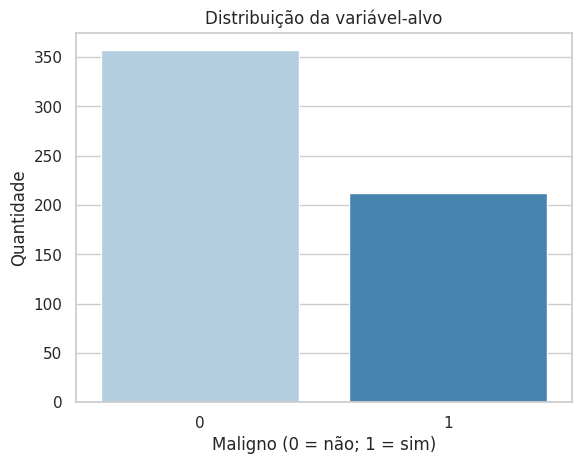

In [ ]:
display(df.describe().T)

contagem_classes = df["maligno"].value_counts().sort_index()
percentual_classes = df["maligno"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "quantidade": contagem_classes,
    "percentual": percentual_classes.round(2)
}))

ax = sns.countplot(data=df, x="maligno", palette="Blues")
ax.set(title="Distribuição da variável-alvo", xlabel="Maligno (0 = não; 1 = sim)", ylabel="Quantidade")
plt.show()

**Interpretação:** a classe não é perfeitamente equilibrada. Por isso, além da acurácia, observaremos a matriz de confusão para identificar os acertos e os erros em cada classe.

### 1.5 Relações entre algumas variáveis

Uma matriz com todas as variáveis seria visualmente carregada. Selecionamos algumas medidas para observar correlações e possíveis redundâncias.

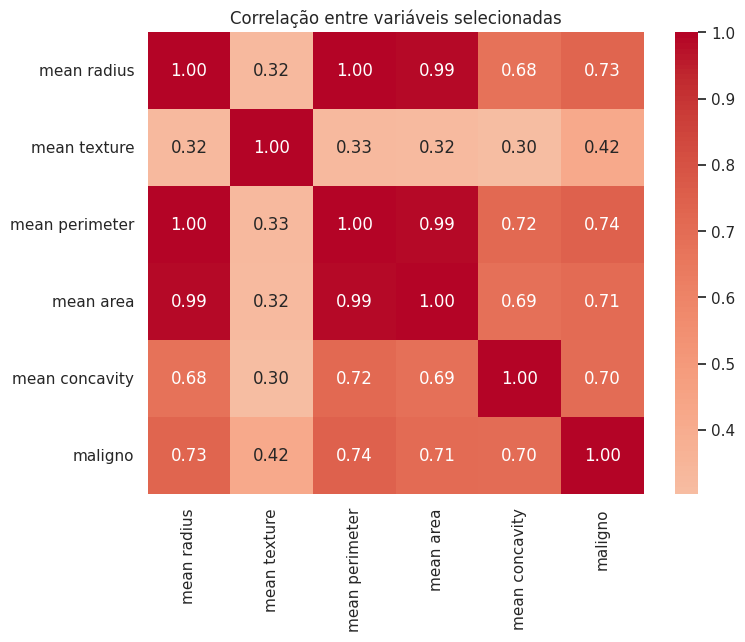

In [ ]:
colunas_exemplo = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean concavity", "maligno"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas_exemplo].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre variáveis selecionadas")
plt.show()

### 1.6 Separação entre preditores e alvo

In [ ]:
X = df.drop(columns="maligno")
y = df["maligno"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Proporção da classe positiva no treino:", y_train.mean().round(3))
print("Proporção da classe positiva no teste:", y_test.mean().round(3))

Treino: (426, 30)
Teste: (143, 30)
Proporção da classe positiva no treino: 0.373
Proporção da classe positiva no teste: 0.371


### 1.7 Pré-processamento e modelo linear

A regressão logística é um algoritmo de classificação linear. Como as variáveis estão em escalas diferentes, aplicamos padronização. O `Pipeline` garante que o escalonador seja ajustado somente com os dados de treino, reduzindo o risco de vazamento de dados.

In [ ]:
modelo_logistico = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

modelo_logistico.fit(X_train, y_train)
y_pred_log = modelo_logistico.predict(X_test)
y_pred_log[:10]

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

### 1.8 Avaliação da regressão logística

Acurácia: 0.965


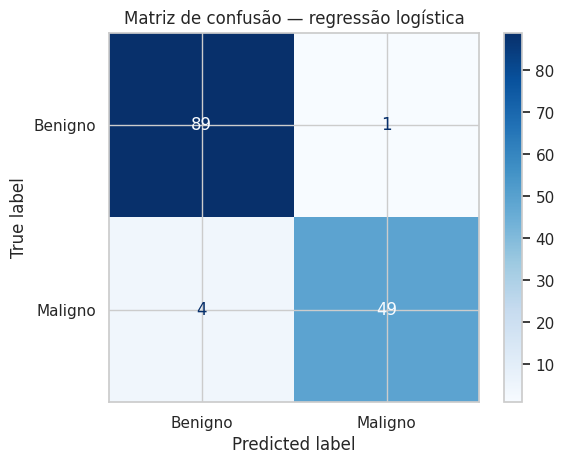

In [ ]:
acuracia_log = accuracy_score(y_test, y_pred_log)
print(f"Acurácia: {acuracia_log:.3f}")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=["Benigno", "Maligno"],
    cmap="Blues"
)
plt.title("Matriz de confusão — regressão logística")
plt.show()

### 1.9 Comparação com outro algoritmo

A árvore de decisão não precisa de padronização para realizar suas divisões. O objetivo aqui não é declarar um vencedor universal, mas comparar o desempenho dos modelos no mesmo conjunto de teste.

In [ ]:
modelo_arvore = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
modelo_arvore.fit(X_train, y_train)
y_pred_arvore = modelo_arvore.predict(X_test)
resultados = pd.DataFrame({
    "modelo": ["Regressão logística", "Árvore de decisão"],
    "acurácia": [acuracia_log, accuracy_score(y_test, y_pred_arvore)]
})

display(resultados.round(3))

,modelo,acurácia
0,Regressão logística,0.965
1,Árvore de decisão,0.895


### 1.10 Conclusão do exemplo

Os dois modelos foram treinados com os mesmos dados e comparados pela acurácia. A matriz de confusão permite observar quais classes foram confundidas. Mesmo com um bom resultado, este exercício é apenas didático e não permite utilizar o modelo para diagnóstico médico.

# Exercício 2 — Economia: classificação de faixa de renda
## Atividade guiada

Utilize o conjunto **Adult**, do UCI Machine Learning Repository. O objetivo é prever se a renda anual de uma pessoa pertence à classe `>50K` ou `<=50K`, com base em atributos censitários.

Página da fonte: <https://www.kaggle.com/datasets/uciml/adult-census-income>

As células seguintes contêm apenas comentários orientadores. Substitua os comentários pelo código necessário, preservando as explicações em Markdown e registrando suas interpretações.

### 2.1 Carregar o arquivo CSV

Baixe ou disponibilize o arquivo da base na sessão. Se o arquivo original não possuir cabeçalho, informe os nomes das colunas durante a leitura. Confirme também como os valores ausentes estão representados.

In [ ]:
# Defina o caminho ou a URL do arquivo CSV.
# Crie a lista com os nomes das colunas, caso o arquivo não possua cabeçalho.
# Carregue o arquivo com pd.read_csv().
# Considere espaços após a vírgula e o símbolo usado para valores ausentes.
# Exiba as cinco primeiras linhas.

In [ ]:
# Caminho do arquivo
csv_exc2 = "/content/adult.csv"
# Carregar o arquivo
df = pd.read_csv(
    csv_exc2,
    skipinitialspace=True,
    na_values="?"
)

# Exibir as cinco primeiras linhas
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### 2.2 Realizar a inspeção inicial

In [ ]:
# Informe a quantidade de linhas e colunas.
# Exiba uma amostra dos dados.
# Mostre os tipos de dados e o uso de memória com info().
# Identifique a coluna que será usada como variável-alvo.

In [ ]:
# Informe a quantidade de linhas e colunas
print("Quantidade de linhas e colunas:", df.shape)

# Exiba uma amostra dos dados
display(df.sample(5, random_state=42))

# Mostre os tipos de dados e o uso de memória
df.info()

# Identifique a coluna que será usada como variável-alvo
print("Variável-alvo: income")

Quantidade de linhas e colunas: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
14160,29,Private,280618,Some-college,10,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States,<=50K
27048,19,Private,439779,Some-college,10,Never-married,Sales,Own-child,White,Male,0,0,15,United-States,<=50K
28868,28,Private,204734,Some-college,10,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,40,United-States,<=50K
5667,35,Private,107991,11th,7,Never-married,Sales,Not-in-family,White,Male,0,0,45,United-States,<=50K
7827,20,Private,54152,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,30,NaN,<=50K


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
Variável-alvo: income


### 2.3 Verificar a qualidade dos dados

In [ ]:
# Conte os valores ausentes por coluna.
# Calcule o percentual de valores ausentes.
# Conte os registros duplicados.
# Decida se os registros duplicados serão removidos e justifique em Markdown.
# Verifique valores inesperados nas colunas categóricas mais importantes.

In [ ]:
# Valores ausentes por coluna
print("=== VALORES AUSENTES POR COLUNA ===")
print(df.isnull().sum())

# Percentual de valores ausentes
print("\n=== PERCENTUAL DE VALORES AUSENTES ===")
print((df.isnull().sum() / len(df) * 100).round(2))

# Registros duplicados
print("\n=== REGISTROS DUPLICADOS ===")
print("Quantidade:", df.duplicated().sum())

# Valores das colunas categóricas
print("\n=== VALORES DAS COLUNAS CATEGÓRICAS ===")

colunas_categoricas = df.select_dtypes(include='object').columns

for coluna in colunas_categoricas:
    print(f"\n{coluna}:")
    print(df[coluna].value_counts(dropna=False))

=== VALORES AUSENTES POR COLUNA ===
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

=== PERCENTUAL DE VALORES AUSENTES ===
age               0.00
workclass         5.64
fnlwgt            0.00
education         0.00
education.num     0.00
marital.status    0.00
occupation        5.66
relationship      0.00
race              0.00
sex               0.00
capital.gain      0.00
capital.loss      0.00
hours.per.week    0.00
native.country    1.79
income            0.00
dtype: float64

=== REGISTROS DUPLICADOS ===
Quantidade: 24

=== VALORES DAS COLUNAS CATEGÓRICAS ===

workclass:
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
NaN                 

### Tratamento de registros duplicados

Não foram identificados registros duplicados no conjunto de dados. Portanto, não foi necessário realizar a remoção desses registros.

### 2.4 Desenvolver a análise exploratória

In [ ]:
# Gere estatísticas descritivas para as variáveis numéricas.
# Exiba a distribuição absoluta e percentual da variável-alvo.
# Construa pelo menos dois gráficos relevantes para o problema.
# Compare a variável-alvo com pelo menos uma variável numérica e uma categórica.

=== ESTATÍSTICAS DESCRITIVAS ===


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



=== DISTRIBUIÇÃO ABSOLUTA DA VARIÁVEL-ALVO ===
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

=== DISTRIBUIÇÃO PERCENTUAL DA VARIÁVEL-ALVO ===
income
<=50K    75.92
>50K     24.08
Name: proportion, dtype: float64


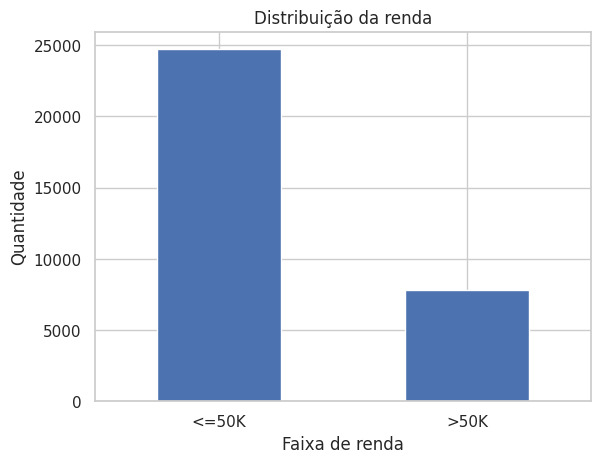

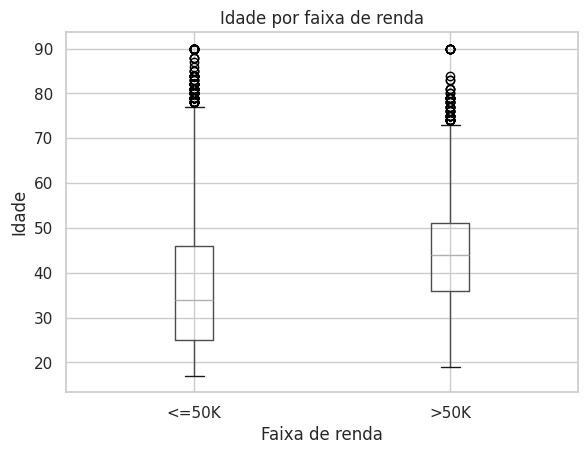


=== MÉDIA DE IDADE POR FAIXA DE RENDA ===
income
<=50K    36.783738
>50K     44.249841
Name: age, dtype: float64

=== RENDA POR SEXO ===
income  <=50K  >50K
sex                
Female   9592  1179
Male    15128  6662


In [ ]:
# Estatísticas descritivas das variáveis numéricas
print("=== ESTATÍSTICAS DESCRITIVAS ===")
display(df.describe())

# Distribuição absoluta da variável-alvo
print("\n=== DISTRIBUIÇÃO ABSOLUTA DA VARIÁVEL-ALVO ===")
print(df['income'].value_counts())

# Distribuição percentual da variável-alvo
print("\n=== DISTRIBUIÇÃO PERCENTUAL DA VARIÁVEL-ALVO ===")
print((df['income'].value_counts(normalize=True) * 100).round(2))

# Gráfico 1 - Distribuição da variável-alvo
df['income'].value_counts().plot(kind='bar')
plt.title('Distribuição da renda')
plt.xlabel('Faixa de renda')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

# Gráfico 2 - Idade por faixa de renda
df.boxplot(column='age', by='income')
plt.title('Idade por faixa de renda')
plt.suptitle('')
plt.xlabel('Faixa de renda')
plt.ylabel('Idade')
plt.show()

# Comparação da variável-alvo com uma variável numérica
print("\n=== MÉDIA DE IDADE POR FAIXA DE RENDA ===")
print(df.groupby('income')['age'].mean())

# Comparação da variável-alvo com uma variável categórica
print("\n=== RENDA POR SEXO ===")
print(pd.crosstab(df['sex'], df['income']))

**Interpretação da análise exploratória:** escreva aqui de três a cinco observações sustentadas pelas tabelas ou gráficos produzidos. Não apresente relações observadas como relações de causa e efeito.

### 2.5 Separar variáveis preditoras e alvo

In [ ]:
# Crie X com as variáveis preditoras.
# Crie y com a variável-alvo.
# Se necessário, converta os rótulos da classe para 0 e 1.
# Verifique as dimensões de X e y.

In [ ]:
# Criar as variáveis preditoras (X) e a variável-alvo (y)

X = df.drop(columns=["income"])

# Converter a variável-alvo para 0 e 1
# 0 = <=50K
# 1 = >50K
y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Verificar as dimensões
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

# Verificar a distribuição da variável-alvo
print("\nDistribuição da variável-alvo:")
print(y.value_counts())

print("\nDistribuição percentual:")
print((y.value_counts(normalize=True) * 100).round(2))

Dimensão de X: (32561, 14)
Dimensão de y: (32561,)

Distribuição da variável-alvo:
income
0    24720
1     7841
Name: count, dtype: int64

Distribuição percentual:
income
0    75.92
1    24.08
Name: proportion, dtype: float64


### 2.6 Dividir os dados

In [ ]:
# Divida X e y em treino e teste.
# Use test_size=0.25, random_state=42 e stratify=y.
# Exiba as dimensões dos subconjuntos.
# Compare a proporção das classes no treino e no teste.

In [ ]:
# Divisão dos dados em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Exibir as dimensões dos subconjuntos
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Comparar a proporção das classes
print("\n=== PROPORÇÃO DAS CLASSES NO TREINO ===")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\n=== PROPORÇÃO DAS CLASSES NO TESTE ===")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train: (24420, 14)
X_test: (8141, 14)
y_train: (24420,)
y_test: (8141,)

=== PROPORÇÃO DAS CLASSES NO TREINO ===
income
0    75.92
1    24.08
Name: proportion, dtype: float64

=== PROPORÇÃO DAS CLASSES NO TESTE ===
income
0    75.92
1    24.08
Name: proportion, dtype: float64


### 2.7 Realizar o pré-processamento básico

In [ ]:
# Identifique as colunas numéricas e categóricas.
# Trate os valores ausentes, caso existam.
# Converta as variáveis categóricas para valores numéricos.
# Explique brevemente as decisões tomadas.
# Confira o resultado após o tratamento.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identificar colunas numéricas e categóricas
colunas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns
colunas_categoricas = X_train.select_dtypes(include=["object"]).columns

print("Colunas numéricas:")
print(list(colunas_numericas))

print("\nColunas categóricas:")
print(list(colunas_categoricas))

# Pipeline para variáveis numéricas
pipeline_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variáveis categóricas
pipeline_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Aplicar os tratamentos
preprocessador = ColumnTransformer([
    ("num", pipeline_numerico, colunas_numericas),
    ("cat", pipeline_categorico, colunas_categoricas)
])

# Ajustar o pré-processamento apenas com os dados de treino
X_train_preprocessado = preprocessador.fit_transform(X_train)

# Aplicar a transformação nos dados de teste
X_test_preprocessado = preprocessador.transform(X_test)

print("\nDimensão após o pré-processamento:")
print("Treino:", X_train_preprocessado.shape)
print("Teste:", X_test_preprocessado.shape)

Colunas numéricas:
['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Colunas categóricas:
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

Dimensão após o pré-processamento:
Treino: (24420, 104)
Teste: (8141, 104)


### 2.8 Treinar um modelo linear

In [ ]:
# Crie um modelo LogisticRegression.
# Treine o modelo com os dados de treino.
# Gere as previsões para os dados de teste.

In [ ]:
# Criar o modelo de Regressão Logística
modelo_logistico = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Treinar o modelo
modelo_logistico.fit(X_train_preprocessado, y_train)

# Gerar previsões para os dados de teste
y_pred_logistico = modelo_logistico.predict(X_test_preprocessado)

print("Modelo de Regressão Logística treinado com sucesso!")

print("\nPrimeiras previsões:")
print(y_pred_logistico[:20])

Modelo de Regressão Logística treinado com sucesso!

Primeiras previsões:
[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1]


### 2.9 Avaliar o modelo

In [ ]:
# Calcule a acurácia do modelo.
# Construa a matriz de confusão.
# Explique, em Markdown, o que o resultado mostra.

Acurácia da Regressão Logística: 0.8522
Acurácia em porcentagem: 85.22%


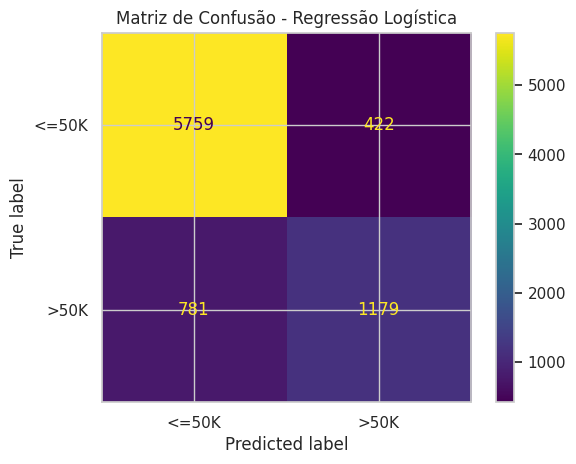

In [ ]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Calcular a acurácia
acuracia_logistica = accuracy_score(
    y_test,
    y_pred_logistico
)

print(f"Acurácia da Regressão Logística: {acuracia_logistica:.4f}")
print(f"Acurácia em porcentagem: {acuracia_logistica * 100:.2f}%")

# Construir a matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistico,
    display_labels=["<=50K", ">50K"]
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

### 2.10 Comparar com um segundo algoritmo

In [ ]:
# Escolha DecisionTreeClassifier ou RandomForestClassifier.
# Mantenha a mesma divisão de treino e teste.
# Treine o segundo modelo e calcule sua acurácia.
# Organize os resultados dos dois modelos em um DataFrame.
# Indique qual modelo apresentou o melhor resultado nessa divisão dos dados.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar o segundo modelo
modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Treinar o modelo com os mesmos dados de treino
modelo_random_forest.fit(
    X_train_preprocessado,
    y_train
)

# Fazer previsões nos mesmos dados de teste
y_pred_random_forest = modelo_random_forest.predict(
    X_test_preprocessado
)

# Calcular a acurácia
acuracia_random_forest = accuracy_score(
    y_test,
    y_pred_random_forest
)

print(f"Acurácia da Random Forest: {acuracia_random_forest:.4f}")
print(f"Acurácia em porcentagem: {acuracia_random_forest * 100:.2f}%")

# Organizar os resultados em um DataFrame
resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Random Forest"
    ],
    "Acurácia": [
        acuracia_logistica,
        acuracia_random_forest
    ]
})

# Mostrar em porcentagem
resultados["Acurácia (%)"] = resultados["Acurácia"] * 100

display(resultados)

# Indicar o melhor modelo
melhor_modelo = resultados.loc[
    resultados["Acurácia"].idxmax(),
    "Modelo"
]

print(f"\nMelhor modelo nessa divisão dos dados: {melhor_modelo}")

Acurácia da Random Forest: 0.8482
Acurácia em porcentagem: 84.82%


,Modelo,Acurácia,Acurácia (%)
0,Regressão Logística,0.852229,85.222946
1,Random Forest,0.848176,84.817590



Melhor modelo nessa divisão dos dados: Regressão Logística


### 2.11 Conclusão do Exercício 2

Responda:

1. Qual modelo apresentou a maior acurácia?
2. O resultado foi semelhante para as duas classes?
3. O que a matriz de confusão mostrou?
4. Qual é a principal limitação desta análise?



1.  **Qual modelo apresentou a maior acurácia?**
    A Regressão Logística apresentou uma acurácia de 85.22%, ligeiramente superior à Random Forest, que obteve 84.82% de acurácia. Portanto, neste conjunto de dados e com as configurações utilizadas, o modelo de Regressão Logística foi o que teve a maior acurácia.

2.  **O resultado foi semelhante para as duas classes?**
    Não, o resultado não foi semelhante para as duas classes. A classe `<=50K` (majoritária) foi classificada com maior precisão do que a classe `>50K` (minoritária). Houve um número significativamente maior de Falsos Negativos (781, ou seja, previu `<=50K` quando na verdade era `>50K`) em comparação com os Falsos Positivos (422, ou seja, previu `>50K` quando na verdade era `<=50K`). Isso sugere que o modelo tem mais dificuldade em identificar corretamente a classe de renda mais alta.

3.  **O que a matriz de confusão mostrou?**
    A matriz de confusão da Regressão Logística mostrou:
    *   **5759** casos de `<=50K` corretamente classificados (Verdadeiros Negativos).
    *   **1179** casos de `>50K` corretamente classificados (Verdadeiros Positivos).
    *   **422** casos de `<=50K` erroneamente classificados como `>50K` (Falsos Positivos).
    *   **781** casos de `>50K` erroneamente classificados como `<=50K` (Falsos Negativos).
    
    Ela revelou uma performance robusta na identificação da classe majoritária, mas uma dificuldade maior em prever a classe minoritária (`>50K`), especialmente evidenciada pelos Falsos Negativos.

4.  **Qual é a principal limitação desta análise?**
    A principal limitação desta análise é o **desequilíbrio das classes** na variável-alvo (`income`). A classe `<=50K` representa a maioria dos dados (75.92%), enquanto a classe `>50K` é minoritária (24.08%). Isso pode levar o modelo a ser enviesado para a classe majoritária, resultando em uma boa acurácia geral, mas um desempenho inferior na identificação da classe minoritária, como visto pelos Falsos Negativos. Além disso, a análise não incluiu técnicas mais avançadas para lidar com o desequilíbrio de classes ou otimização de hiperparâmetros, que poderiam melhorar a capacidade do modelo de prever a classe minoritária.

# Exercício 3 — Desafio real
## Construção e demonstração de uma solução de classificação

Cada grupo deve escolher **um** dos quatro temas abaixo. A base deve ser obtida em formato CSV ou convertida para CSV antes da análise. O grupo deverá construir uma solução completa, sem reutilizar diretamente o código resolvido.

| Tema | Dataset sugerido | Problema de classificação |
|---|---|---|
| Saúde | Parkinson's — UCI | Classificar registros de voz associados ou não à doença de Parkinson (`status`). |
| Economia | Bank Marketing — UCI | Prever se um cliente contratará um depósito a prazo (`y`). |
| Energia | Electrical Grid Stability — UCI | Classificar a rede simulada como estável ou instável (`stabf`). |
| Telecomunicações | Iranian Churn — UCI | Prever a ocorrência de evasão de clientes (`Churn`). |

### Fontes

- Saúde: <https://archive.ics.uci.edu/dataset/174/parkinsons>
- Economia: <https://archive.ics.uci.edu/dataset/222/bank+marketing>
- Energia: <https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data>
- Telecomunicações: <https://archive.ics.uci.edu/dataset/563/iranian+churn>

O grupo pode propor outro dataset Kaggle ou UCI dentro de um dos quatro temas, desde que obtenha aprovação do professor e identifique claramente a fonte, a variável-alvo e o significado de cada classe.

## 3.1 Definição do problema

Preencha antes de programar:

- **Tema escolhido:**
- **Fonte e link do dataset:**
- **Unidade representada por cada linha:**
- **Variável-alvo:**
- **Significado das classes:**
- **Decisão que o modelo pretende apoiar:**
- **Possíveis consequências de falsos positivos:**
- **Possíveis consequências de falsos negativos:**

## 3.2 Requisitos da implementação

O notebook do grupo deve conter, nesta ordem:

1. carga dos dados a partir de um arquivo CSV;
2. descrição do dataset e da variável-alvo;
3. inspeção de dimensões, tipos e amostra;
4. verificação de ausentes, duplicados e valores inconsistentes;
5. análise da distribuição das classes;
6. pelo menos três visualizações relevantes;
7. separação entre `X` e `y`;
8. divisão entre treino e teste;
9. pré-processamento adequado aos tipos de variáveis;
10. treinamento de uma regressão logística;
11. treinamento de pelo menos um segundo algoritmo do `scikit-learn`;
12. comparação da acurácia dos modelos;
13. matriz de confusão;
14. conclusão com o resultado e as limitações.

### Condições técnicas

- Não remova valores ou variáveis sem justificar.
- Caso crie uma classe a partir de uma variável numérica, documente o limiar e evite vazamento dessa variável para os preditores.

## 3.3 Desenvolvimento

Crie abaixo as células de Markdown e código necessárias. Organize o trabalho com subtítulos claros e mantenha os resultados da última execução visíveis na entrega.

In [ ]:
# Inicie aqui a implementação do desafio.
# Adicione novas células conforme a estrutura solicitada.

## 3.1 Definição do problema

- **Tema escolhido:** Saúde
- **Fonte e link do dataset:** UCI Machine Learning Repository — Parkinson's Disease Data Set — https://archive.ics.uci.edu/dataset/174/parkinsons
- **Unidade representada por cada linha:** cada linha é uma gravação de voz (amostra) de um paciente; cada paciente possui várias gravações no dataset.
- **Variável-alvo:** `status`
- **Significado das classes:** `status = 1` → a gravação pertence a um paciente diagnosticado com Parkinson; `status = 0` → a gravação pertence a um indivíduo saudável.
- **Decisão que o modelo pretende apoiar:** auxiliar (não substituir) um profissional de saúde numa triagem inicial por voz, indicando quais pacientes merecem avaliação clínica mais aprofundada.
- **Possíveis consequências de falsos positivos:** paciente saudável classificado como doente → exames clínicos desnecessários, ansiedade e custo extra.
- **Possíveis consequências de falsos negativos:** paciente com Parkinson classificado como saudável → atraso no diagnóstico e no início do tratamento.

##3.2 Implementação


In [ ]:
#1 carga dos dados a partir de um arquivo CSV;
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/parkinsons.csv')

df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 2. Descrição do dataset e da variável-alvo

O dataset contém 195 gravações de voz coletadas de 31 pessoas, sendo 23 pessoas com Parkinson e 8 saudáveis. Como foram realizadas várias gravações por pessoa, cada linha representa uma gravação, e não necessariamente uma pessoa diferente.

O conjunto possui 24 colunas: a coluna `name`, a variável-alvo `status` e 22 medidas acústicas da voz. Essas medidas incluem frequência vocal, variação da frequência, variação da amplitude, ruído e medidas não lineares.

A variável-alvo é `status`:

- `0` representa uma pessoa saudável;
- `1` representa uma pessoa com Parkinson.

## 3. Inspeção de dimensões, tipos e amostra

In [ ]:
print("Dimensões (linhas, colunas):", df.shape)
df.info()

Dimensões (linhas, colunas): (195, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR  

In [ ]:
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,0.015664,0.017878,0.024081,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,0.010153,0.012024,0.016947,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,0.004550,0.005700,0.007190,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,0.008245,0.009580,0.013080,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,0.012790,0.013470,0.018260,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,0.020265,0.022380,0.029400,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,0.056470,0.079400,0.137780,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


## 4. Verificação de ausentes, duplicados e valores inconsistentes

In [ ]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())

print("\nTotal de valores ausentes:")
print(df.isnull().sum().sum())

print("\nQuantidade de linhas duplicadas:")
print(df.duplicated().sum())

print("\nValores encontrados na variável status:")
print(df['status'].unique())

colunas_numericas = df.select_dtypes(include=np.number).columns

print("\nValores infinitos por coluna:")
print(np.isinf(df[colunas_numericas]).sum())

Valores ausentes por coluna:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

Total de valores ausentes:
0

Quantidade de linhas duplicadas:
0

Valores encontrados na variável status:
[1 0]

Valores infinitos por coluna:
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0


### Resultado da verificação

Não foram encontrados valores ausentes, linhas duplicadas ou valores infinitos. A variável-alvo possui somente os valores esperados, 0 e 1. Portanto, não foi necessário remover ou preencher registros.

## 5. Análise da distribuição das classes

In [ ]:
contagem = df['status'].value_counts()
percentual = df['status'].value_counts(normalize=True) * 100

print(contagem)
print(percentual.round(1))

status
1    147
0     48
Name: count, dtype: int64
status
1    75.4
0    24.6
Name: proportion, dtype: float64


### Análise da distribuição

O dataset está desbalanceado. A classe com Parkinson representa aproximadamente 75% dos registros, enquanto a classe saudável representa aproximadamente 25%. Por isso, a acurácia não deve ser analisada sozinha nas próximas etapas.

## 6. Visualizações

### 6.1 Distribuição das classes

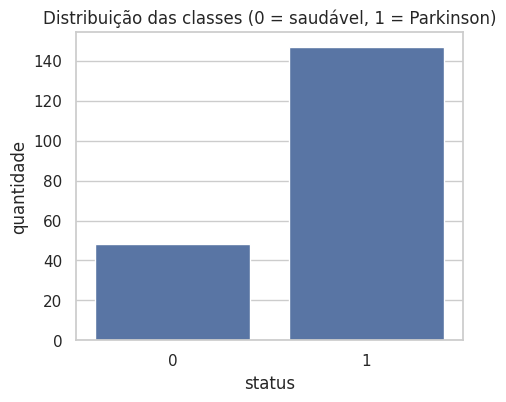

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='status', data=df)
plt.title('Distribuição das classes (0 = saudável, 1 = Parkinson)')
plt.xlabel('status')
plt.ylabel('quantidade')
plt.show()

### 6.2 Distribuição da frequência fundamental da voz

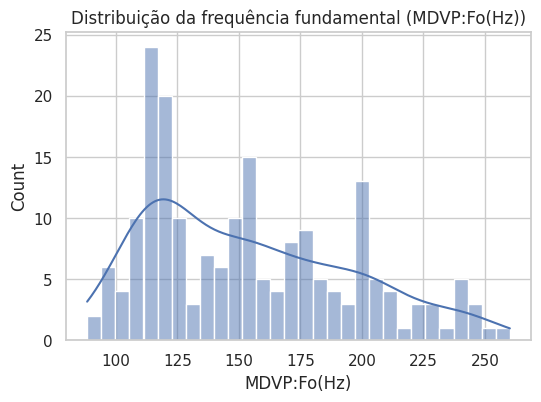

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['MDVP:Fo(Hz)'], bins=30, kde=True)
plt.title('Distribuição da frequência fundamental (MDVP:Fo(Hz))')
plt.show()

### 6.3 Jitter (%) comparado entre as classes

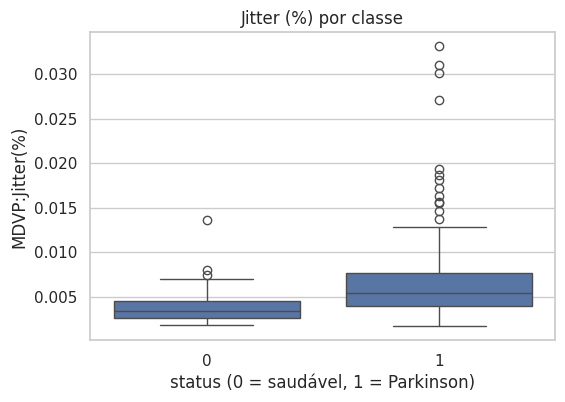

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='status', y='MDVP:Jitter(%)', data=df)
plt.title('Jitter (%) por classe')
plt.xlabel('status (0 = saudável, 1 = Parkinson)')
plt.show()

### Análise das visualizações

O gráfico de distribuição confirma que existem mais registros associados ao Parkinson do que registros saudáveis.

A comparação da variável PPE indica que os registros associados ao Parkinson tendem a apresentar valores mais elevados. Também podem ser observadas diferenças nas medidas de frequência vocal e HNR, embora exista sobreposição entre as classes.

Isso mostra que uma única variável pode não ser suficiente para realizar a classificação, justificando o uso conjunto das características pelo modelo.

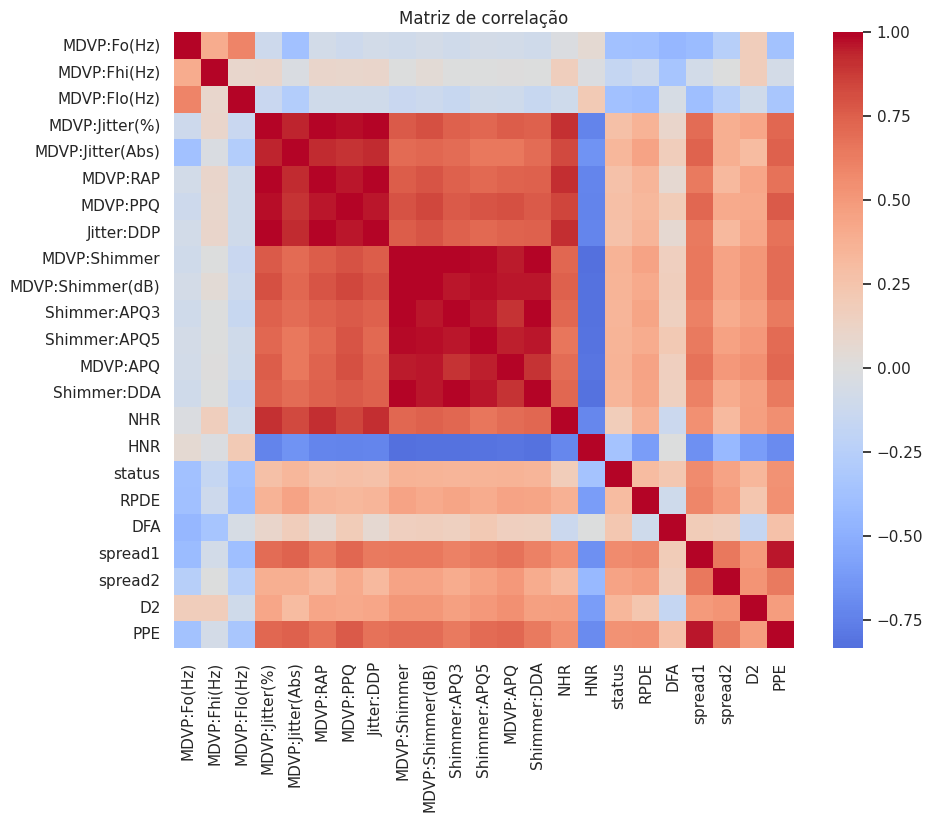

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=['name']).corr(), cmap='coolwarm', center=0)
plt.title('Matriz de correlação')
plt.show()

#7. Separação entre X e y

In [ ]:
X = df.drop(columns=['name', 'status'])
y = df['status']

print("X:", X.shape, "| y:", y.shape)

X: (195, 22) | y: (195,)


## Separação entre X e y

A variável `status` foi definida como a variável-alvo `y`. As medidas acústicas foram utilizadas como variáveis preditoras em `X`.

A coluna `name` não deve ser utilizada como preditora porque funciona apenas como identificação do indivíduo e da gravação, não representando uma característica acústica da voz.

## 8. Divisão entre treino e teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape[0], "amostras")
print("Teste:", X_test.shape[0], "amostras")

Treino: 156 amostras
Teste: 39 amostras


## Divisão entre treino e teste

Os dados foram divididos em conjuntos de treino e teste. O conjunto de treino será utilizado para ensinar os modelos, enquanto o conjunto de teste será utilizado para avaliar o desempenho em dados que não participaram do treinamento.

A separação estratificada mantém aproximadamente a mesma proporção das classes nos dois conjuntos.

## 9. Pré-processamento

Todas as variáveis são numéricas contínuas, mas em escalas bem diferentes (Hz, %, valores adimensionais). Como a Regressão Logística e o KNN são sensíveis à escala das variáveis, aplicamos padronização (`StandardScaler`), ajustada apenas com os dados de treino para evitar vazamento de informação do teste.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Pré-processamento

Após a retirada da coluna identificadora, todas as variáveis preditoras são numéricas. Como não foram encontrados valores ausentes, não foi necessário realizar preenchimento.

As variáveis foram padronizadas para ficarem em escalas comparáveis. O pré-processamento foi ajustado somente com os dados de treino para evitar o vazamento de informações do conjunto de teste.

## 10. Regressão Logística

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)
print(f"Acurácia (Regressão Logística): {acc_log:.3f}")

Acurácia (Regressão Logística): 0.923


## Treinamento da regressão logística

A regressão logística foi escolhida como primeiro modelo de classificação. Apesar do nome, esse algoritmo é utilizado para prever classes, calculando a probabilidade de um registro pertencer à classe saudável ou à classe Parkinson.

O modelo foi treinado utilizando os dados de treino previamente padronizados.

## 11. Segundo algoritmo: KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Acurácia (KNN): {acc_knn:.3f}")

Acurácia (KNN): 0.923


## Treinamento do segundo algoritmo

O segundo algoritmo escolhido foi o K-Nearest Neighbors (KNN). Esse modelo classifica cada novo registro com base nas classes dos registros mais próximos.

Como o KNN utiliza distâncias entre os dados, a padronização das variáveis é importante para impedir que características com valores maiores dominem o cálculo.

## 12. Comparação da acurácia dos modelos

In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'KNN (k=5)'],
    'Acurácia': [acc_log, acc_knn]
})
resultados

,Modelo,Acurácia
0,Regressão Logística,0.923077
1,KNN (k=5),0.923077


## 3.4 Conclusão técnica do grupo

Apresente uma conclusão com:

- síntese dos padrões observados na análise exploratória;
- comparação da acurácia dos modelos;
- leitura básica da matriz de confusão;
- limitações do conjunto de dados e da modelagem;
- melhorias que seriam testadas em uma próxima versão.

Não declare que o modelo “comprova”, “garante” ou “prevê perfeitamente” um resultado.

## Comparação da acurácia dos modelos

A acurácia representa a proporção de previsões corretas realizadas pelo modelo. Nesta etapa, as acurácias da regressão logística e do KNN são comparadas.

Entretanto, como o dataset está desbalanceado, a acurácia não deve ser utilizada isoladamente. Também é necessário analisar os tipos de erros apresentados nas matrizes de confusão.

## 13. Matriz de confusão

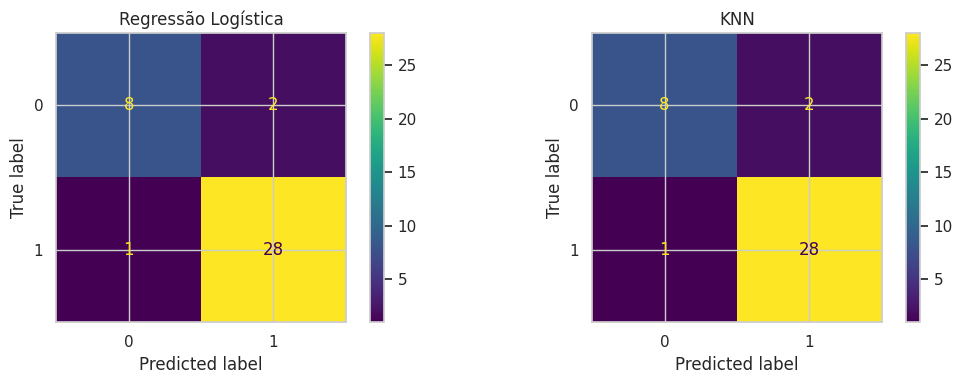

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log)).plot(ax=axes[0])
axes[0].set_title('Regressão Logística')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn)).plot(ax=axes[1])
axes[1].set_title('KNN')

plt.tight_layout()
plt.show()

##  Matrizes de confusão

As matrizes de confusão mostram a quantidade de previsões corretas e incorretas de cada modelo:

- **Verdadeiro negativo:** registro saudável classificado corretamente;
- **Falso positivo:** registro saudável classificado como Parkinson;
- **Falso negativo:** registro com Parkinson classificado como saudável;
- **Verdadeiro positivo:** registro com Parkinson classificado corretamente.

Neste problema, os falsos negativos merecem atenção especial, pois representam pessoas com Parkinson classificadas pelo modelo como saudáveis.

##  Conclusão e limitações

A regressão logística e o KNN conseguiram classificar a maioria dos registros de voz corretamente. A comparação das acurácias e das matrizes de confusão permitiu observar não apenas a quantidade total de acertos, mas também os falsos positivos e falsos negativos produzidos por cada modelo.

Os resultados mostram que características acústicas da voz podem contribuir para a identificação de registros associados à doença de Parkinson. Entretanto, o modelo deve ser considerado apenas uma ferramenta de apoio à triagem, e não um substituto para o diagnóstico médico.

Entre as principais limitações estão o pequeno número de participantes, o desbalanceamento das classes e a existência de várias gravações da mesma pessoa. Além disso, o desempenho foi avaliado utilizando apenas uma divisão entre treino e teste. Estudos futuros poderiam utilizar mais dados, validação cruzada e outros algoritmos de classificação.

# Parte 2 — Apresentação e demonstração

O grupo deverá demonstrar a implementação escolhida no Exercício 3. A apresentação deve evidenciar compreensão do processo, e não apenas mostrar o notebook pronto.

## Roteiro sugerido

1. **Problema e dados:** tema, fonte, unidade de análise, variável-alvo e classes.
2. **Análise exploratória:** dois ou três achados relevantes e possíveis problemas da base.
3. **Pré-processamento:** o que foi feito e por que foi necessário.
4. **Modelagem:** algoritmos escolhidos e forma de divisão dos dados.
5. **Resultados:** comparação da acurácia e leitura da matriz de confusão.
6. **Decisão:** modelo selecionado, limitações e melhorias futuras.

## Durante a demonstração

- execute ou apresente células essenciais do fluxo;
- explique uma transformação de pré-processamento;
- mostre como as previsões são geradas;
- interprete ao menos um erro da matriz de confusão;
- responda às perguntas do professor sobre decisões do grupo.

> Todos os integrantes podem ser questionados sobre qualquer parte entregue.

# Critérios de avaliação

## Parte 1 — Implementação: 70 pontos

| Critério | Pontos |
|---|---:|
| Carga, compreensão e organização dos dados | 10 |
| Análise exploratória e qualidade das interpretações | 15 |
| Pré-processamento básico dos dados | 15 |
| Treinamento correto e comparação dos modelos | 15 |
| Acurácia, matriz de confusão e interpretação | 10 |
| Conclusão, limitações e organização do notebook | 5 |

## Parte 2 — Apresentação: 30 pontos

| Critério | Pontos |
|---|---:|
| Clareza na contextualização do problema e dos dados | 5 |
| Demonstração do fluxo implementado | 10 |
| Interpretação dos resultados e justificativa das decisões | 10 |
| Participação e domínio do grupo | 5 |

**Total: 100 pontos**

# Checklist final

- [ ] Identificação do grupo preenchida.
- [ ] Exercício 2 concluído e interpretado.
- [ ] Exercício 3 desenvolvido com um dos quatro temas.
- [ ] CSV utilizado está acessível ou sua obtenção está documentada.
- [ ] Notebook executado do início ao fim sem erros.
- [ ] Resultados e gráficos permanecem visíveis.
- [ ] Dois ou mais modelos foram comparados.
- [ ] Acurácia e matriz de confusão foram interpretadas.
- [ ] Conclusão inclui limitações.
- [ ] Grupo está preparado para demonstrar e explicar a implementação.